## **Dhruv's Contribution | DDQN**

In [1]:
import gymnasium as gym
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Reward Shaping and Q-Network Architecture in Reinforcement Learning

In [2]:
# Reward shaping wrapper
class RewardWrapper(gym.RewardWrapper):
    def __init__(self, env, hole_penalty=-0.5):
        super().__init__(env)
        self.hole_penalty = hole_penalty

    def reward(self, reward):
        if reward == 0:
            return -0.01
        elif reward == 1:
            return 1.0
        else:
            return self.hole_penalty

# Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=128):
        super(QNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_size)
        )

    def forward(self, x):
        return self.model(x)

## Replay Buffer and One-Hot Encoding for Reinforcement Learning

In [3]:
# Replay Buffer
class ReplayBuffer:
    def __init__(self, buffer_size=100000):
        self.buffer = deque(maxlen=buffer_size)

    def push(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

# One-hot encoding
def one_hot(state, size):
    vec = np.zeros(size)
    vec[state] = 1.0
    return vec


## DDQN Training

In [4]:
def train_ddqn(env, num_episodes=50000, gamma=0.99, epsilon=1.0, epsilon_min=0.01,
               epsilon_decay=0.99, batch_size=32, lr=1e-3, target_update=20,
               hidden_size=128):

    state_size = env.observation_space.n
    action_size = env.action_space.n

    q_net = QNetwork(state_size, action_size, hidden_size=hidden_size)
    target_net = QNetwork(state_size, action_size, hidden_size=hidden_size)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    buffer = ReplayBuffer()

    all_returns = []
    variances = []
    compute_times = []
    max_avg_return = -float("inf")
    return_rolling = deque(maxlen=100)
    convergence_episode = None
    success_count = 0

    for episode in range(num_episodes):
        t0 = time.time()

        state, _ = env.reset(seed=SEED + episode)
        state = one_hot(state, state_size)
        done = False
        total_reward = 0

        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = torch.argmax(q_net(torch.tensor(state, dtype=torch.float32))).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if reward == 1.0:
                success_count += 1
            next_state_onehot = one_hot(next_state, state_size)
            buffer.push((state, action, reward, next_state_onehot, done))
            state = next_state_onehot
            total_reward += reward

            if len(buffer) >= batch_size:
                transitions = buffer.sample(batch_size)
                states, actions, rewards, next_states, dones = zip(*transitions)
                states = torch.tensor(np.array(states), dtype=torch.float32)
                actions = torch.tensor(actions, dtype=torch.int64)
                rewards = torch.tensor(rewards, dtype=torch.float32)
                next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
                dones = torch.tensor(dones, dtype=torch.float32)

                q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                next_q_values = q_net(next_states)
                best_actions = torch.argmax(next_q_values, dim=1)
                next_q_target = target_net(next_states).gather(1, best_actions.unsqueeze(1)).squeeze()
                targets = rewards + gamma * next_q_target * (1 - dones)

                loss = nn.MSELoss()(q_values, targets.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        return_rolling.append(total_reward)
        all_returns.append(total_reward)
        compute_times.append(time.time() - t0)

        if episode % target_update == 0:
            target_net.load_state_dict(q_net.state_dict())

        avg_return = np.mean(return_rolling)
        if avg_return > max_avg_return:
            max_avg_return = avg_return

        if avg_return >= 0.7 and convergence_episode is None:
            convergence_episode = episode

        variances.append(np.var(return_rolling))

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1} | Avg Return (last 100): {avg_return:.2f} | Epsilon: {epsilon:.3f} | Successes: {success_count}")

    print(f"\n Training complete. Successes: {success_count}/{num_episodes}")
    return all_returns, variances, compute_times, convergence_episode, max_avg_return, q_net


In [5]:
# Main
if __name__ == "__main__":
    env = RewardWrapper(gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False), hole_penalty=-0.5)

    print("\n==== Initial Training ====")
    returns, variances, times, conv_ep, best_avg, q_net = train_ddqn(env)


==== Initial Training ====
Episode 100 | Avg Return (last 100): -0.08 | Epsilon: 0.366 | Successes: 1
Episode 200 | Avg Return (last 100): 0.07 | Epsilon: 0.134 | Successes: 23
Episode 300 | Avg Return (last 100): 0.45 | Epsilon: 0.049 | Successes: 94
Episode 400 | Avg Return (last 100): 0.74 | Epsilon: 0.018 | Successes: 184
Episode 500 | Avg Return (last 100): 0.19 | Epsilon: 0.010 | Successes: 248
Episode 600 | Avg Return (last 100): 0.89 | Epsilon: 0.010 | Successes: 345
Episode 700 | Avg Return (last 100): 0.64 | Epsilon: 0.010 | Successes: 432
Episode 800 | Avg Return (last 100): 0.90 | Epsilon: 0.010 | Successes: 530
Episode 900 | Avg Return (last 100): 0.93 | Epsilon: 0.010 | Successes: 629
Episode 1000 | Avg Return (last 100): 0.89 | Epsilon: 0.010 | Successes: 727
Episode 1100 | Avg Return (last 100): 0.89 | Epsilon: 0.010 | Successes: 825
Episode 1200 | Avg Return (last 100): 0.92 | Epsilon: 0.010 | Successes: 923
Episode 1300 | Avg Return (last 100): -0.08 | Epsilon: 0.010

## PLOTS

In [6]:
# Plotting
def plot_metrics(returns, variances, times, convergence_episode, max_avg_return):
    episodes = np.arange(len(returns))

    rolling_avg = np.convolve(returns, np.ones(100)/100, mode='valid')
    plt.figure()
    plt.plot(rolling_avg)
    plt.title("Average Episodic Return (Rolling 100)")
    plt.xlabel("Episode")
    plt.ylabel("Avg Return")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(variances)
    plt.title("Variance of Episodic Return")
    plt.xlabel("Episode")
    plt.ylabel("Variance")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(times)
    plt.title("Compute Time per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Seconds")
    plt.grid(True)
    plt.show()

    x_percent = 0.9
    target = x_percent * max_avg_return
    efficiency_episode = next((i for i, r in enumerate(rolling_avg) if r >= target), None)
    print(f"\nSample Efficiency: Reached {x_percent*100:.0f}% of best avg return at episode {efficiency_episode}")
    print(f"Convergence Episode: {convergence_episode}")
    print(f"Max Avg Return over 100 episodes: {max_avg_return:.2f}")

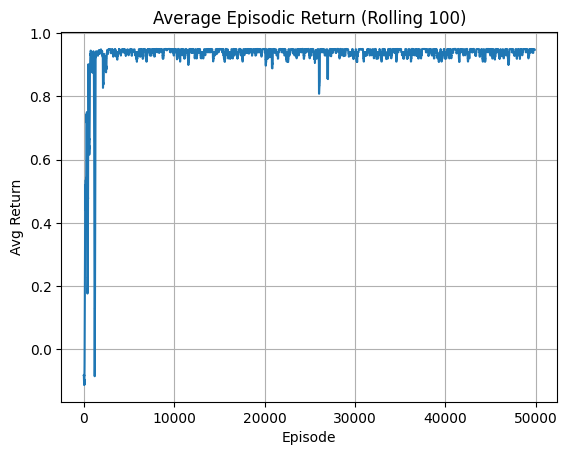

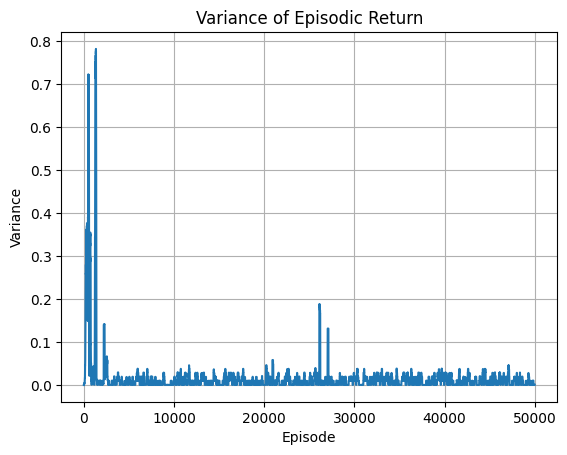

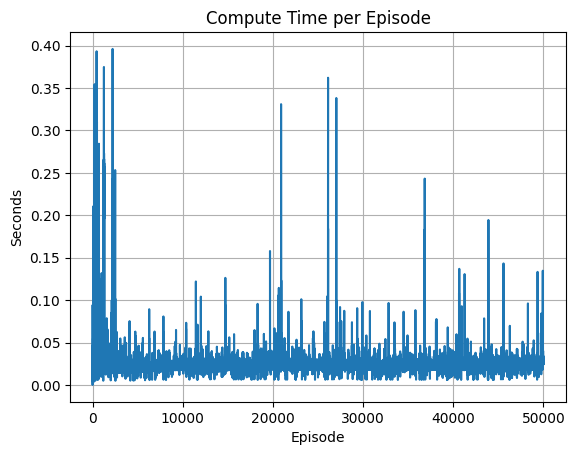


Sample Efficiency: Reached 90% of best avg return at episode 497
Convergence Episode: 386
Max Avg Return over 100 episodes: 0.95


In [7]:
# Main
if __name__ == "__main__":
  plot_metrics(returns, variances, times, conv_ep, best_avg)

## Agent Testing with Q-Network and One-Hot Encoding

In [8]:
# Testing
def test_agent(env, q_net, episodes=100, render=False):
    state_size = env.observation_space.n
    success_count = 0
    total_rewards = []

    for episode in range(episodes):
        state, _ = env.reset(seed=SEED + episode)
        state = one_hot(state, state_size)
        done = False
        total_reward = 0

        while not done:
            if render:
                env.render()
                time.sleep(0.1)

            with torch.no_grad():
                action = torch.argmax(q_net(torch.tensor(state, dtype=torch.float32))).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            state = one_hot(next_state, state_size)

        total_rewards.append(total_reward)
        if total_reward > 0:
            success_count += 1

    print(f"\n Test Results over {episodes} episodes:")
    print(f" - Success Rate: {success_count}/{episodes} = {success_count/episodes:.2f}")
    print(f" - Avg Total Reward: {np.mean(total_rewards):.2f}")
    return success_count / episodes  # Return success rate

In [9]:
# Main
if __name__ == "__main__":
  print("\n==== Testing BEFORE Tuning ====")
  base_accuracy = test_agent(env, q_net)


==== Testing BEFORE Tuning ====

 Test Results over 100 episodes:
 - Success Rate: 100/100 = 1.00
 - Avg Total Reward: 0.95


## Grid Search Tuning

In [10]:
def run_grid_search():
    env_config = {"map_name": "4x4", "is_slippery": False}

    lrs = [1e-3, 5e-4]
    eps_decays = [0.99]
    hidden_sizes = [128, 256]
    hole_penalties = [-0.5, -1.0]

    results = []
    best_success_rate = -1
    best_config = None

    for lr in lrs:
        for eps_decay in eps_decays:
            for hidden in hidden_sizes:
                for hole_penalty in hole_penalties:
                    print(f"\n Running config: lr={lr}, decay={eps_decay}, hidden={hidden}, hole_penalty={hole_penalty}")

                    env = RewardWrapper(gym.make("FrozenLake-v1", **env_config), hole_penalty=hole_penalty)

                    returns, variances, times, conv_ep, max_avg, q_net = train_ddqn(
                        env,
                        gamma=0.99,
                        epsilon=1.0,
                        epsilon_min=0.01,
                        epsilon_decay=eps_decay,
                        batch_size=32,
                        lr=lr,
                        target_update=20,
                        hidden_size=hidden,
                        num_episodes=5000
                    )

                    rolling_avg = np.convolve(returns, np.ones(100)/100, mode='valid')
                    threshold = 0.9 * max_avg
                    efficiency_episode = next((i for i, r in enumerate(rolling_avg) if r >= threshold), None)

                    success_rate = test_agent(env, q_net, episodes=50)

                    result = {
                        "lr": lr,
                        "eps_decay": eps_decay,
                        "hidden_size": hidden,
                        "hole_penalty": hole_penalty,
                        "convergence_episode": conv_ep,
                        "max_avg_return": max_avg,
                        "efficiency_episode": efficiency_episode,
                        "test_success_rate": success_rate
                    }
                    results.append(result)

                    if success_rate > best_success_rate:
                        best_success_rate = success_rate
                        best_config = result
                        best_q_net = q_net

    print("\n=== Grid Search Summary ===")
    for res in results:
        print(res)

    print("\n=== Best Configuration Found ===")
    for k, v in best_config.items():
        print(f"{k}: {v}")

    # Final testing on best configuration
    print("\n==== Final Testing on Best Tuned Agent ====")
    env = RewardWrapper(gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False), hole_penalty=best_config["hole_penalty"])
    test_agent(env, best_q_net)

In [11]:
# Main
if __name__ == "__main__":
  print("\n==== Running Grid Search ====")
  run_grid_search()


==== Running Grid Search ====

 Running config: lr=0.001, decay=0.99, hidden=128, hole_penalty=-0.5
Episode 100 | Avg Return (last 100): -0.09 | Epsilon: 0.366 | Successes: 0
Episode 200 | Avg Return (last 100): 0.20 | Epsilon: 0.134 | Successes: 27
Episode 300 | Avg Return (last 100): 0.57 | Epsilon: 0.049 | Successes: 98
Episode 400 | Avg Return (last 100): 0.90 | Epsilon: 0.018 | Successes: 196
Episode 500 | Avg Return (last 100): 0.95 | Epsilon: 0.010 | Successes: 296
Episode 600 | Avg Return (last 100): 0.93 | Epsilon: 0.010 | Successes: 395
Episode 700 | Avg Return (last 100): 0.94 | Epsilon: 0.010 | Successes: 495
Episode 800 | Avg Return (last 100): 0.93 | Epsilon: 0.010 | Successes: 593
Episode 900 | Avg Return (last 100): 0.95 | Epsilon: 0.010 | Successes: 693
Episode 1000 | Avg Return (last 100): 0.90 | Epsilon: 0.010 | Successes: 790
Episode 1100 | Avg Return (last 100): 0.93 | Epsilon: 0.010 | Successes: 889
Episode 1200 | Avg Return (last 100): 0.93 | Epsilon: 0.010 | Su

## SUMMARY

1. Best Configuration: The optimal hyperparameters were found with a learning rate of 0.001, epsilon decay of 0.99, and a hidden layer size of 128. The agent also received a hole penalty of -0.5.

2. Convergence and Efficiency: The agent converged by episode 361 and demonstrated efficient exploration starting around episode 294, consistently selecting the optimal action.

3. Final Performance: In the final testing phase, the agent achieved a success rate of 100% over 100 episodes, indicating perfect performance. Additionally, the average total reward per episode was 0.95, reflecting high cumulative reward over time.

4. Test Success Rate: A success rate of 1.00 shows that the agent effectively learned the task and applied it during testing, confirming the agent's strong learning and decision-making abilities.

## LLM PROMPTS:- 

1. What happens if I change the learning rate to 0.005 and the epsilon decay to 0.995?
2. Can I visualize exploration efficiency with a 50-step window instead of 100?